# Market Silver EDA
EDA riêng cho coverage, chất lượng OHLCV, return và volatility của VN30.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
market = pd.read_parquet(ROOT / 'data_lake/silver/market_daily')
market['session_date'] = pd.to_datetime(market.session_date.astype(str))
print(f'Market rows: {len(market):,}')

Market rows: 52,142


In [2]:
quality = pd.Series({
    'rows': len(market),
    'tickers': market.ticker.nunique(),
    'sessions': market.session_date.nunique(),
    'first_session': market.session_date.min(),
    'last_session': market.session_date.max(),
    'duplicate_keys': market.duplicated(['ticker','session_date','interval','source']).sum(),
    'invalid_rows': (~market.is_valid).sum(),
    'weekend_rows': market.session_date.dt.dayofweek.ge(5).sum(),
    'missing_daily_return': market.daily_return.isna().sum(),
    'abs_return_gt_10pct': market.daily_return.abs().gt(.10).sum(),
}, name='value').to_frame()
display(quality)

,value
rows,52142
tickers,30
sessions,1788
first_session,2019-12-02 00:00:00
last_session,2026-10-07 00:00:00
duplicate_keys,0
invalid_rows,0
weekend_rows,0
missing_daily_return,30
abs_return_gt_10pct,46


,sessions,first_session,last_session,missing_return
ticker,,,,
BCM,1443,2021-03-15,2026-10-07,1
SSB,1445,2021-03-24,2026-10-07,1
ACB,1519,2020-12-09,2026-10-07,1
VIB,1542,2020-11-10,2026-10-07,1
GVR,1703,2020-03-17,2026-10-07,1
VNM,1774,2019-12-02,2026-10-07,1
VCB,1774,2019-12-02,2026-10-07,1
TCB,1774,2019-12-02,2026-10-07,1
STB,1774,2019-12-02,2026-10-07,1


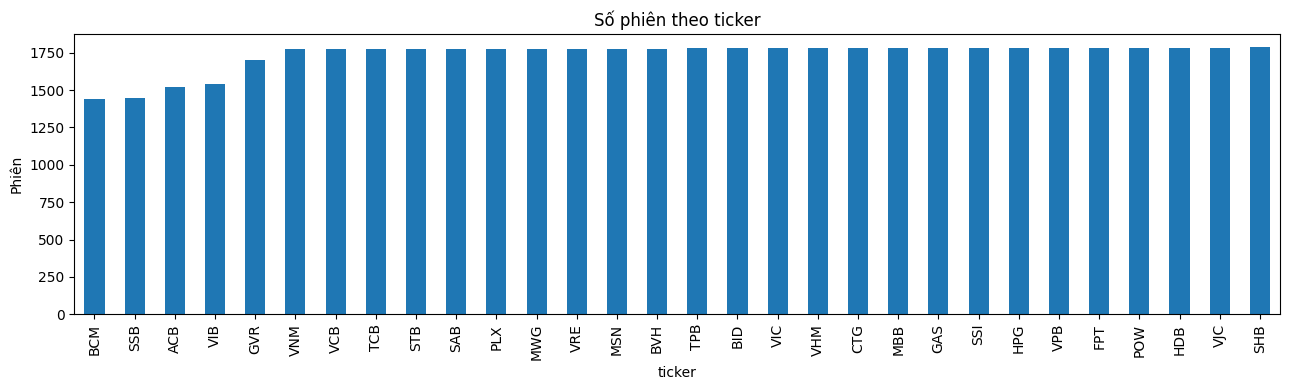

In [3]:
coverage = market.groupby('ticker').agg(
    sessions=('session_date','nunique'),
    first_session=('session_date','min'),
    last_session=('session_date','max'),
    missing_return=('daily_return', lambda s: s.isna().sum()),
).sort_values('sessions')
display(coverage)
coverage.sessions.plot.bar(figsize=(13,4), title='Số phiên theo ticker')
plt.ylabel('Phiên'); plt.tight_layout(); plt.show()

In [4]:
returns = market.daily_return.dropna()
return_summary = returns.describe(percentiles=[.01,.05,.5,.95,.99]).to_frame('value')
return_summary['unit'] = '%'
return_summary.loc['count', 'unit'] = 'rows'
return_summary.loc[return_summary.index != 'count', 'value'] *= 100
display(return_summary.rename(columns={'value':'daily_return'}))

,daily_return,unit
count,52112.000000,rows
mean,0.064297,%
std,2.157295,%
min,-49.539880,%
1%,-6.868627,%
5%,-3.234342,%
50%,0.000000,%
95%,3.664246,%
99%,6.874999,%
max,31.250000,%


,mean_return,volatility,median_volume
ticker,,,
GVR,0.113302,2.835023,2368900.0
SHB,0.128701,2.646165,24847933.0
SSI,0.111392,2.590218,22104715.0
VRE,0.011075,2.470883,4130100.0
STB,0.135536,2.401022,10710290.0
TCB,0.055398,2.385573,6877050.0
VHM,0.068154,2.302428,7714800.0
VIC,0.110127,2.279276,3602500.0
POW,0.035903,2.259786,7812945.0


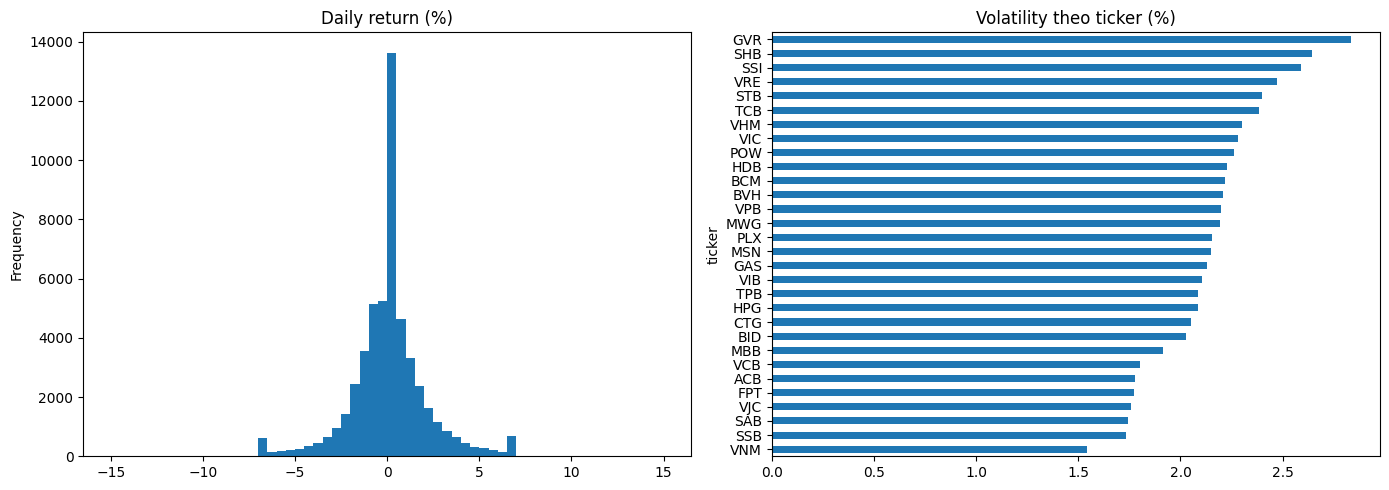

In [5]:
ticker_risk = market.groupby('ticker').agg(
    mean_return=('daily_return','mean'),
    volatility=('daily_return','std'),
    median_volume=('volume','median'),
).sort_values('volatility', ascending=False)
display(ticker_risk.assign(mean_return=lambda x:100*x.mean_return, volatility=lambda x:100*x.volatility))
fig, axes = plt.subplots(1,2,figsize=(14,5))
(100*returns).clip(-15,15).plot.hist(bins=60, ax=axes[0], title='Daily return (%)')
(100*ticker_risk.volatility).sort_values().plot.barh(ax=axes[1], title='Volatility theo ticker (%)')
plt.tight_layout(); plt.show()

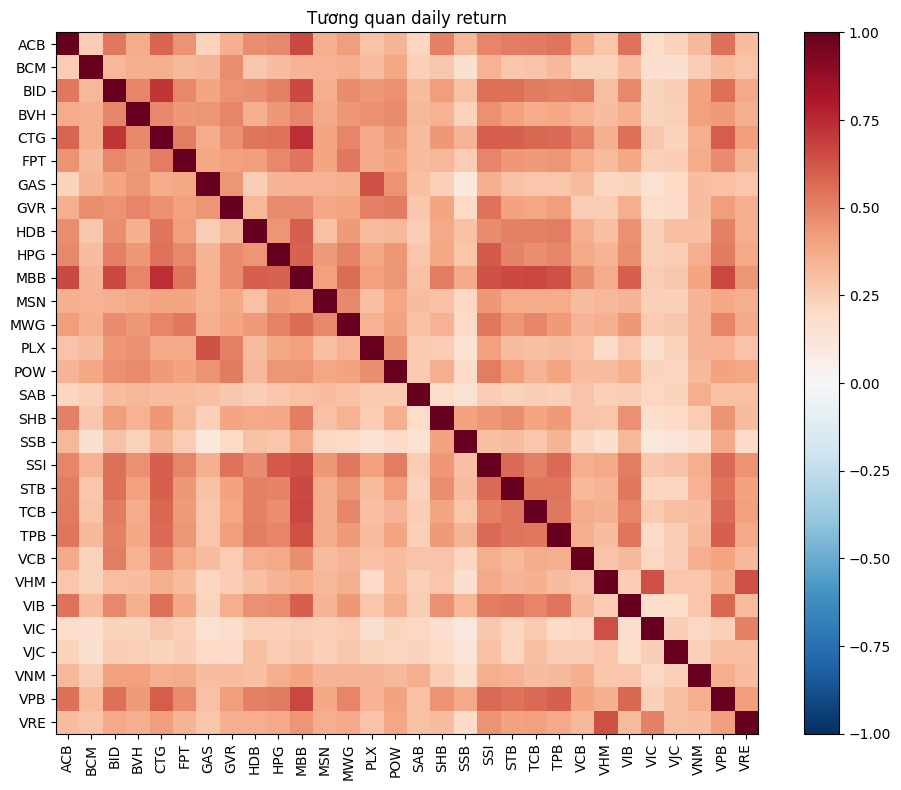

In [6]:
return_matrix = market.pivot(index='session_date', columns='ticker', values='daily_return')
corr = return_matrix.corr(min_periods=100)
fig, ax = plt.subplots(figsize=(10,8))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.index)
ax.set_title('Tương quan daily return')
fig.colorbar(image, ax=ax); plt.tight_layout(); plt.show()